In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard.csv')

print(df.shape)
print(df.isnull().sum().sum(), "missing values")
print(df['Class'].value_counts())
print(f"Fraud percentage: {df['Class'].mean()*100:.3f}%")

(284807, 31)
0 missing values
Class
0    284315
1       492
Name: count, dtype: int64
Fraud percentage: 0.173%


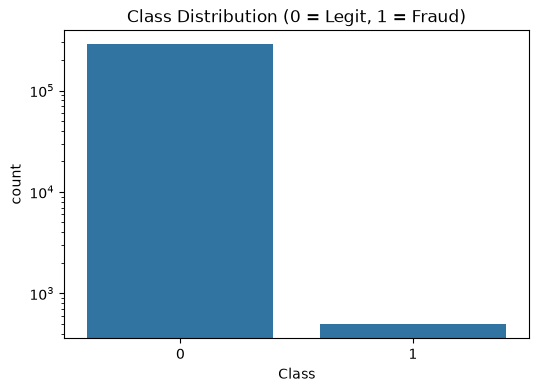

In [2]:
# Class imbalance visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.yscale('log')  # log scale since fraud is so rare
plt.show()

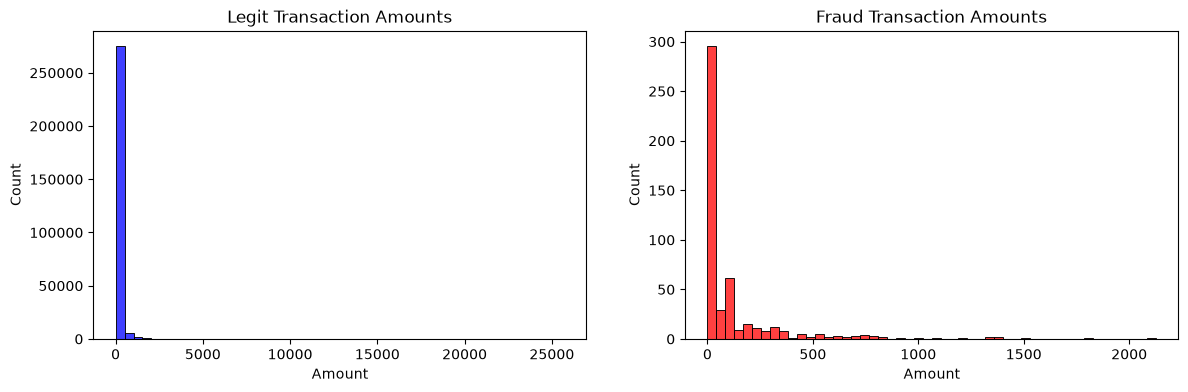

In [3]:
# Amount distribution: fraud vs non-fraud
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df[df['Class']==0]['Amount'], bins=50, ax=ax[0], color='blue')
ax[0].set_title('Legit Transaction Amounts')
sns.histplot(df[df['Class']==1]['Amount'], bins=50, ax=ax[1], color='red')
ax[1].set_title('Fraud Transaction Amounts')
plt.show()

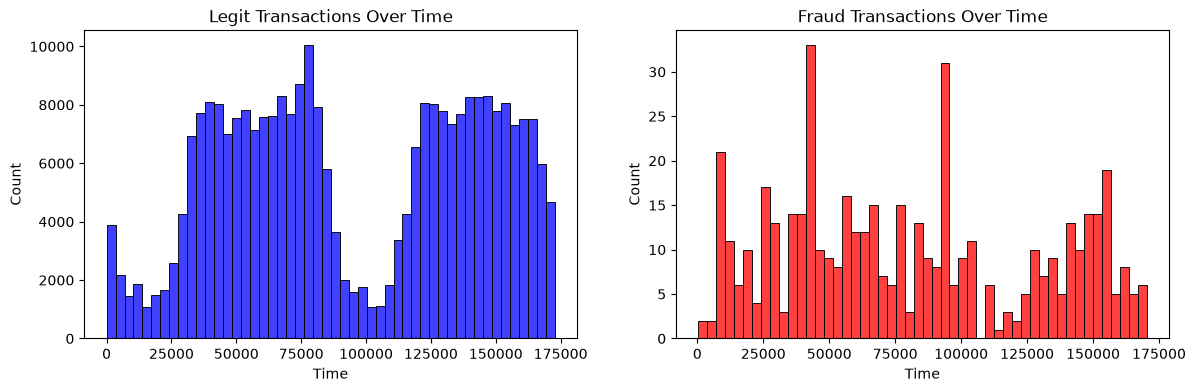

In [4]:
# Time distribution
fig, ax = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(df[df['Class']==0]['Time'], bins=50, ax=ax[0], color='blue')
ax[0].set_title('Legit Transactions Over Time')
sns.histplot(df[df['Class']==1]['Time'], bins=50, ax=ax[1], color='red')
ax[1].set_title('Fraud Transactions Over Time')
plt.show()

In [5]:
# Correlation with target (V1-V28 are PCA components, so this is limited but useful)
corr = df.corr()['Class'].sort_values(ascending=False)
print(corr.head(10))
print(corr.tail(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix

# Scale 'Amount' and 'Time' (other features are already PCA-scaled)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, digits=4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    print(f"PR-AUC: {pr_auc:.4f}")
    return pr_auc

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
evaluate(lr, X_test, y_test, "Logistic Regression")


--- Logistic Regression ---
              precision    recall  f1-score   support

           0     0.9994    0.9998    0.9996     56864
           1     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962

Confusion Matrix:
[[56851    13]
 [   35    63]]
PR-AUC: 0.7428


0.7428054178969038

In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate(rf, X_test, y_test, "Random Forest")


--- Random Forest ---
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9412    0.8163    0.8743        98

    accuracy                         0.9996     56962
   macro avg     0.9704    0.9081    0.9371     56962
weighted avg     0.9996    0.9996    0.9996     56962

Confusion Matrix:
[[56859     5]
 [   18    80]]
PR-AUC: 0.8647


0.864660155175714

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
evaluate(rf_smote, X_test, y_test, "Random Forest + SMOTE")

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}

--- Random Forest + SMOTE ---
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8247    0.8163    0.8205        98

    accuracy                         0.9994     56962
   macro avg     0.9122    0.9080    0.9101     56962
weighted avg     0.9994    0.9994    0.9994     56962

Confusion Matrix:
[[56847    17]
 [   18    80]]
PR-AUC: 0.8698


0.8698021389966673

In [10]:
rf_weighted = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_weighted.fit(X_train, y_train)
evaluate(rf_weighted, X_test, y_test, "Random Forest + Class Weighting")


--- Random Forest + Class Weighting ---
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9186    0.8061    0.8587        98

    accuracy                         0.9995     56962
   macro avg     0.9591    0.9030    0.9292     56962
weighted avg     0.9995    0.9995    0.9995     56962

Confusion Matrix:
[[56857     7]
 [   19    79]]
PR-AUC: 0.8567


0.8566785299674929

In [11]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)
xgb.fit(X_train, y_train)
evaluate(xgb, X_test, y_test, "XGBoost + scale_pos_weight")

scale_pos_weight: 577.2868020304569

--- XGBoost + scale_pos_weight ---
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8737    0.8469    0.8601        98

    accuracy                         0.9995     56962
   macro avg     0.9367    0.9234    0.9299     56962
weighted avg     0.9995    0.9995    0.9995     56962

Confusion Matrix:
[[56852    12]
 [   15    83]]
PR-AUC: 0.8771


0.8771420497698478

In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=15,           # tries 15 random combinations
    scoring='average_precision',  #PR-AUC
    cv=3,                # 3-fold cross-validation
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV PR-AUC:", random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV PR-AUC: 0.8457549452045461


In [13]:
best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr'
)

best_xgb.fit(X_train, y_train)
evaluate(best_xgb, X_test, y_test, "Tuned XGBoost")


--- Tuned XGBoost ---
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8804    0.8265    0.8526        98

    accuracy                         0.9995     56962
   macro avg     0.9401    0.9132    0.9262     56962
weighted avg     0.9995    0.9995    0.9995     56962

Confusion Matrix:
[[56853    11]
 [   17    81]]
PR-AUC: 0.8784


0.8783850557205641

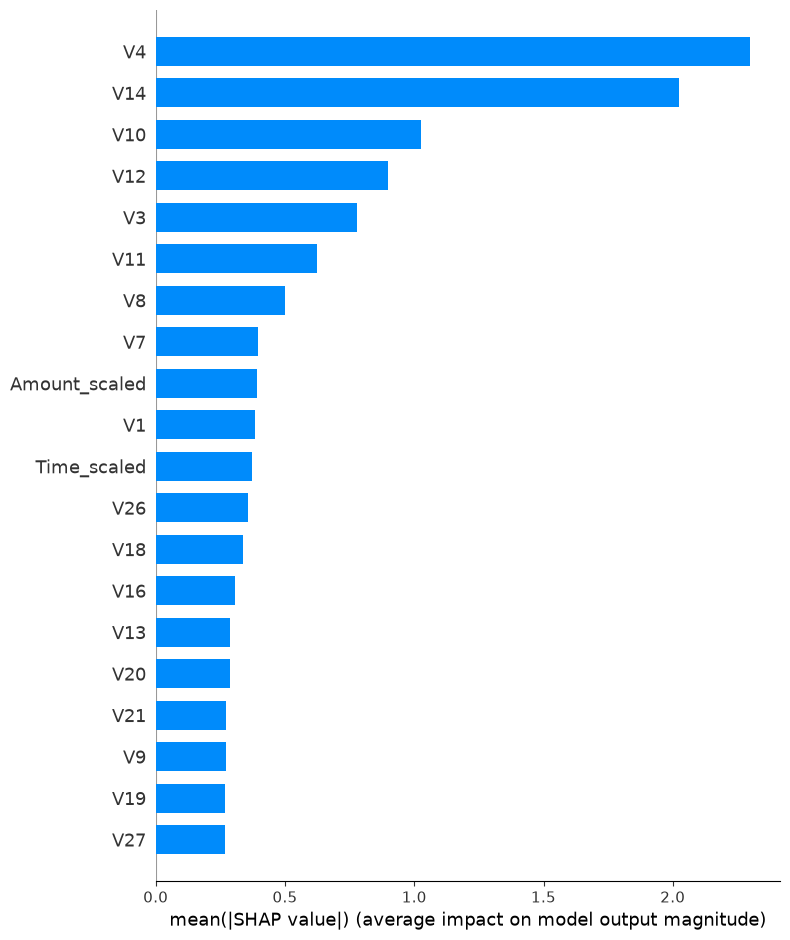

In [14]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

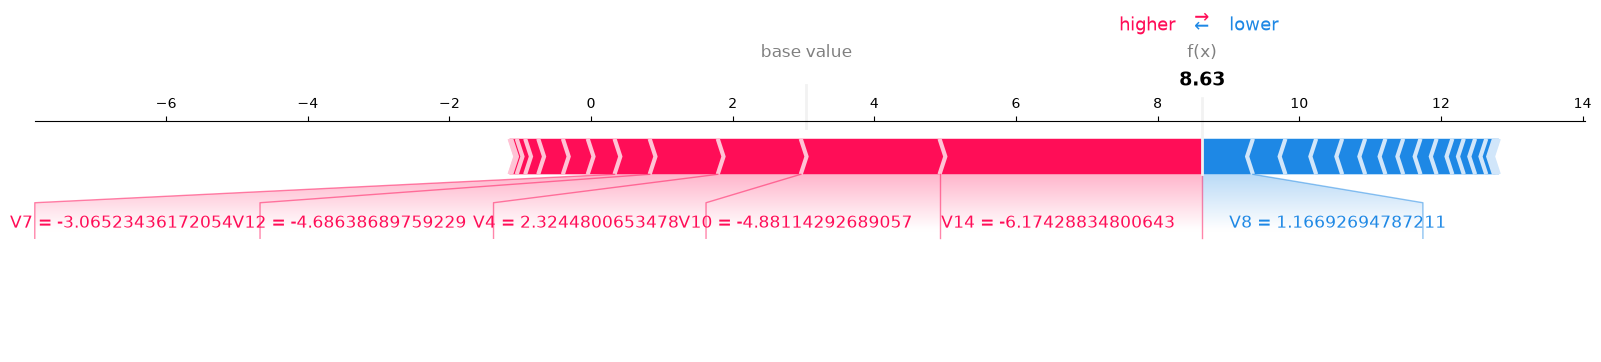

In [15]:
# Pick a fraud case correctly identified by the model
fraud_indices = y_test[y_test == 1].index
sample_idx = X_test.index.get_loc(fraud_indices[0])

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True
)

In [16]:
import joblib

joblib.dump(best_xgb, 'fraud_model.pkl')
print("Model saved!")

Model saved!


In [17]:
import json

feature_names = list(X_train.columns)
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("Feature names saved!")

Feature names saved!
